<a href="https://colab.research.google.com/github/ashrafatoosa-cmyk/Netflix-Stock-Prediction-LSTM/blob/main/Netflix_Stock_Price_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd

# Load the dataset
# Note: In Colab, uploaded files go into the '/content/' folder
df = pd.read_csv('/content/NFLX.csv')

# Look at the first 5 rows of the data
df.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,2018-02-05,262.000000,267.899994,250.029999,254.259995,254.259995,11896100
1,2018-02-06,247.699997,266.700012,245.000000,265.720001,265.720001,12595800
2,2018-02-07,266.579987,272.450012,264.329987,264.559998,264.559998,8981500
3,2018-02-08,267.079987,267.619995,250.000000,250.100006,250.100006,9306700
4,2018-02-09,253.850006,255.800003,236.110001,249.470001,249.470001,16906900


In [3]:
# 1. Check the shape (rows, columns) of the dataset
print("Dataset Shape:", df.shape)

# 2. Check for missing values in each column
print("\nMissing values in each column:")
print(df.isnull().sum())

# 3. Check data types of the columns
print("\nData types:")
print(df.dtypes)# 1. Check the shape (rows, columns) of the dataset
print("Dataset Shape:", df.shape)

# 2. Check for missing values in each column
print("\nMissing values in each column:")
print(df.isnull().sum())

# 3. Check data types of the columns
print("\nData types:")
print(df.dtypes)

Dataset Shape: (1009, 7)

Missing values in each column:
Date         0
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64

Data types:
Date          object
Open         float64
High         float64
Low          float64
Close        float64
Adj Close    float64
Volume         int64
dtype: object
Dataset Shape: (1009, 7)

Missing values in each column:
Date         0
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64

Data types:
Date          object
Open         float64
High         float64
Low          float64
Close        float64
Adj Close    float64
Volume         int64
dtype: object


In [4]:
# Convert Date column to datetime format
df['Date'] = pd.to_datetime(df['Date'])

# Set the Date column as the index of our table
df.set_index('Date', inplace=True)

# Let's see the updated data types and the new look
print(df.dtypes)
df.head()

Open         float64
High         float64
Low          float64
Close        float64
Adj Close    float64
Volume         int64
dtype: object


,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2018-02-05,262.000000,267.899994,250.029999,254.259995,254.259995,11896100
2018-02-06,247.699997,266.700012,245.000000,265.720001,265.720001,12595800
2018-02-07,266.579987,272.450012,264.329987,264.559998,264.559998,8981500
2018-02-08,267.079987,267.619995,250.000000,250.100006,250.100006,9306700
2018-02-09,253.850006,255.800003,236.110001,249.470001,249.470001,16906900


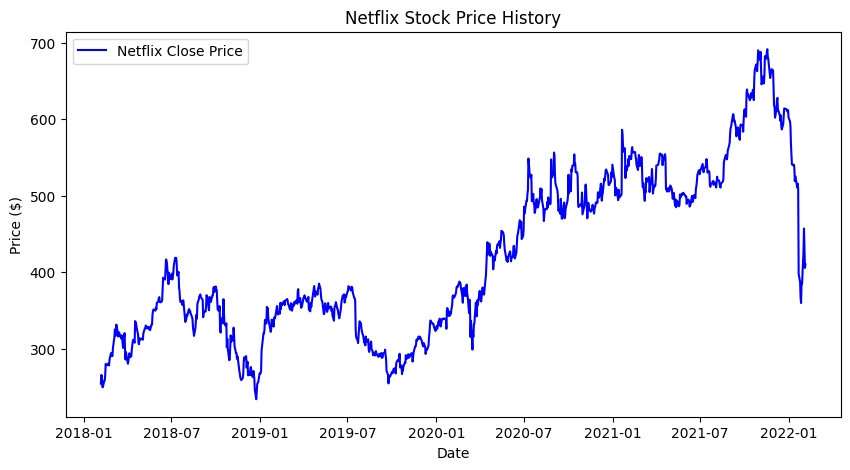

In [5]:
import matplotlib.pyplot as plt

# Plot the 'Close' price column
plt.figure(figsize=(10, 5))
plt.plot(df['Close'], color='blue', label='Netflix Close Price')
plt.title('Netflix Stock Price History')
plt.xlabel('Date')
plt.ylabel('Price ($)')
plt.legend()
plt.show()

In [6]:
import numpy as np
from sklearn.preprocessing import MinMaxScaler

# 1. Isolate the 'Close' column and convert it to a numpy array
data = df.filter(['Close']).values

# 2. Set up the scaler to shrink numbers between 0 and 1
scaler = MinMaxScaler(feature_range=(0, 1))

# 3. Transform the data
scaled_data = scaler.fit_transform(data)

# Let's see what the first 5 scaled prices look like
print("First 5 scaled values:")
print(scaled_data[:5])

First 5 scaled values:
[[0.04451626]
 [0.06954849]
 [0.06701469]
 [0.03542955]
 [0.03405342]]


In [7]:
import math

# 1. Calculate the number of rows to train on (80% of the total data)
training_data_len = math.ceil(len(scaled_data) * 0.8)
print(f"Total rows in dataset: {len(scaled_data)}")
print(f"Number of rows for training (80%): {training_data_len}")

# 2. Split the data into train and test sets
train_data = scaled_data[0:training_data_len, :]
test_data = scaled_data[training_data_len:, :]

print(f"Actual Training set shape: {train_data.shape}")
print(f"Actual Testing set shape: {test_data.shape}")

Total rows in dataset: 1009
Number of rows for training (80%): 808
Actual Training set shape: (808, 1)
Actual Testing set shape: (201, 1)


In [8]:
X_train = []
y_train = []

# Loop through the data to create 60-day sequences
for i in range(60, len(train_data)):
    X_train.append(train_data[i-60:i, 0]) # Past 60 days
    y_train.append(train_data[i, 0])    # The 61st day (Target)

# Convert lists into numpy arrays
X_train, y_train = np.array(X_train), np.array(y_train)

print(f"X_train shape before reshape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")

X_train shape before reshape: (748, 60)
y_train shape: (748,)


In [9]:
# Reshape the data to 3D: (748, 60, 1)
X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))

print(f"X_train final 3D shape: {X_train.shape}")

X_train final 3D shape: (748, 60, 1)


In [10]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Dropout

# 1. Initialize the model
model = Sequential()

# 2. Add the first LSTM layer and Dropout
model.add(LSTM(units=50, return_sequences=True, input_shape=(X_train.shape[1], 1)))
model.add(Dropout(0.2))

# 3. Add the second LSTM layer and Dropout
model.add(LSTM(units=50, return_sequences=False))
model.add(Dropout(0.2))

# 4. Add the output layer (Dense)
model.add(Dense(units=1))

# 5. Compile the model
model.compile(optimizer='adam', loss='mean_squared_error')

# 6. Train the model!
print("Starting training...")
history = model.fit(X_train, y_train, batch_size=32, epochs=10)
print("Training complete!")

Starting training...
Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


24/24 ━━━━━━━━━━━━━━━━━━━━ 5s 49ms/step - loss: 0.0317
Epoch 2/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 84ms/step - loss: 0.0055
Epoch 3/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 69ms/step - loss: 0.0038
Epoch 4/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step - loss: 0.0039
Epoch 5/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step - loss: 0.0034
Epoch 6/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 53ms/step - loss: 0.0031
Epoch 7/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step - loss: 0.0031
Epoch 8/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step - loss: 0.0027
Epoch 9/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step - loss: 0.0031
Epoch 10/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 50ms/step - loss: 0.0032
Training complete!


7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 83ms/step


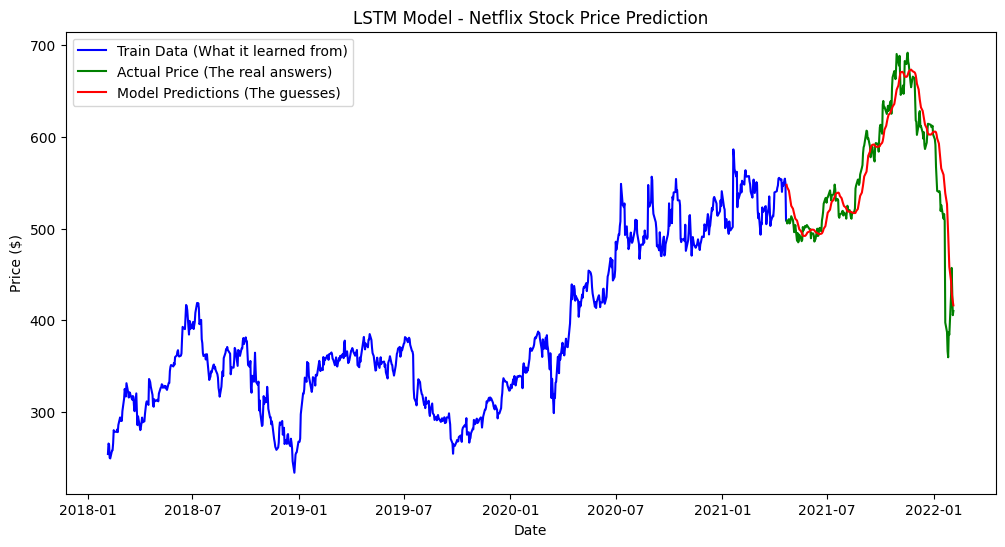

In [11]:
# 1. Prepare the test data windows
test_inputs = scaled_data[len(scaled_data) - len(test_data) - 60:]
X_test = []
actual_prices = df['Close'][training_data_len:].values

for i in range(60, len(test_inputs)):
    X_test.append(test_inputs[i-60:i, 0])

X_test = np.array(X_test)
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))

# 2. Get the model's predictions
predictions = model.predict(X_test)
# Undo the normalization to get actual dollar values
predictions = scaler.inverse_transform(predictions)

# 3. Plot the final results!
train = df[:training_data_len]
valid = df[training_data_len:].copy()
valid['Predictions'] = predictions

plt.figure(figsize=(12, 6))
plt.plot(train['Close'], color='blue', label='Train Data (What it learned from)')
plt.plot(valid['Close'], color='green', label='Actual Price (The real answers)')
plt.plot(valid['Predictions'], color='red', label='Model Predictions (The guesses)')
plt.title('LSTM Model - Netflix Stock Price Prediction')
plt.xlabel('Date')
plt.ylabel('Price ($)')
plt.legend()
plt.show()

In [12]:
# Calculate MAE (Mean Absolute Error)
mae = np.mean(np.abs(actual_prices - predictions.flatten()))

# Calculate WAPE (Weighted Absolute Percentage Error)
wape = np.sum(np.abs(actual_prices - predictions.flatten())) / np.sum(actual_prices)

print(f"Mean Absolute Error (MAE): ${mae:.2f}")
print(f"Weighted Absolute Percentage Error (WAPE): {wape * 100:.2f}%")

Mean Absolute Error (MAE): $20.44
Weighted Absolute Percentage Error (WAPE): 3.66%


In [13]:
# 1. Initialize the deeper model
tuned_model = Sequential()

# Layer 1
tuned_model.add(LSTM(units=100, return_sequences=True, input_shape=(X_train.shape[1], 1)))
tuned_model.add(Dropout(0.2))

# Layer 2 (New extra layer)
tuned_model.add(LSTM(units=100, return_sequences=True))
tuned_model.add(Dropout(0.2))

# Layer 3
tuned_model.add(LSTM(units=100, return_sequences=False))
tuned_model.add(Dropout(0.2))

# Output Layer
tuned_model.add(Dense(units=1))

# 2. Compile
tuned_model.compile(optimizer='adam', loss='mean_squared_error')

# 3. Train for 20 epochs
print("Training the tuned model...")
tuned_model.fit(X_train, y_train, batch_size=32, epochs=20)
print("Tuned model training complete!")

Training the tuned model...
Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


24/24 ━━━━━━━━━━━━━━━━━━━━ 12s 123ms/step - loss: 0.0245
Epoch 2/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 5s 124ms/step - loss: 0.0047
Epoch 3/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 6s 152ms/step - loss: 0.0035
Epoch 4/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 3s 124ms/step - loss: 0.0037
Epoch 5/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 5s 124ms/step - loss: 0.0035
Epoch 6/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 4s 174ms/step - loss: 0.0032
Epoch 7/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 3s 123ms/step - loss: 0.0033
Epoch 8/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 3s 122ms/step - loss: 0.0037
Epoch 9/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 7s 183ms/step - loss: 0.0033
Epoch 10/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 3s 122ms/step - loss: 0.0027
Epoch 11/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 3s 125ms/step - loss: 0.0028
Epoch 12/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 3s 125ms/step - loss: 0.0030
Epoch 13/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 4s 182ms/step - loss: 0.0032
Epoch 14/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 3s 125ms/step - loss: 0.0023
Epoch 15/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 5s 124ms/step - loss: 0.0026

In [14]:
# 1. Get predictions from the new tuned model
tuned_predictions = tuned_model.predict(X_test)
tuned_predictions = scaler.inverse_transform(tuned_predictions)

# 2. Recalculate MAE and WAPE
tuned_mae = np.mean(np.abs(actual_prices - tuned_predictions.flatten()))
tuned_wape = np.sum(np.abs(actual_prices - tuned_predictions.flatten())) / np.sum(actual_prices)

print("--- TUNED MODEL RESULTS ---")
print(f"New Mean Absolute Error (MAE): ${tuned_mae:.2f}")
print(f"New Weighted Absolute Percentage Error (WAPE): {tuned_wape * 100:.2f}%")

7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 108ms/step
--- TUNED MODEL RESULTS ---
New Mean Absolute Error (MAE): $19.18
New Weighted Absolute Percentage Error (WAPE): 3.44%


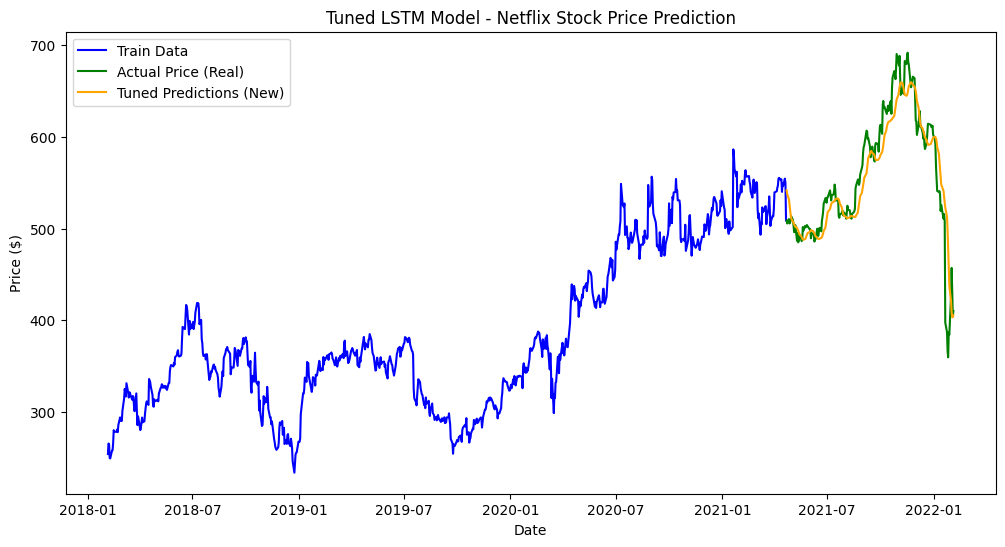

In [15]:
# 1. Prepare the data for the graph
valid_tuned = df[training_data_len:].copy()
valid_tuned['Tuned_Predictions'] = tuned_predictions

# 2. Plot everything
plt.figure(figsize=(12, 6))
plt.plot(train['Close'], color='blue', label='Train Data')
plt.plot(valid_tuned['Close'], color='green', label='Actual Price (Real)')
plt.plot(valid_tuned['Tuned_Predictions'], color='orange', label='Tuned Predictions (New)')
plt.title('Tuned LSTM Model - Netflix Stock Price Prediction')
plt.xlabel('Date')
plt.ylabel('Price ($)')
plt.legend()
plt.show()
